In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from astroquery.jplhorizons import Horizons

In [11]:
asteroid_name = '2004 MN4'

In [12]:
df = pd.read_csv(f'../data/{asteroid_name}_35_1_1_cleaned_lc.csv')
df

,time,detrended_mag,detrended_mag_err
0,2275.605976,0.037861,0.052103
1,2275.612920,-0.063367,0.051678
2,2275.619864,-0.051413,0.051621
3,2275.626809,-0.030249,0.051753
4,2275.633753,-0.046613,0.051736
...,...,...,...
622,2279.953079,0.265565,0.053154
623,2279.960023,0.225865,0.053083
624,2279.966967,0.178031,0.052823
625,2279.973911,0.219797,0.053101


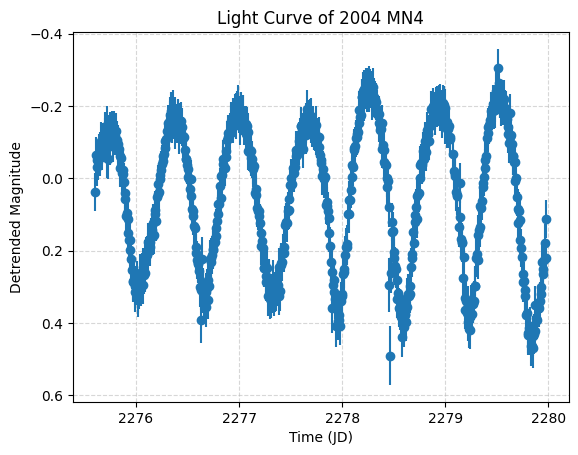

In [4]:
plt.errorbar(df['time'], df['detrended_mag'], yerr=df['detrended_mag_err'], fmt='o')
plt.xlabel('Time (JD)')
plt.ylabel('Detrended Magnitude')
plt.title('Light Curve of 2004 MN4')
plt.gca().invert_yaxis()  # Invert y-axis for magnitude
plt.grid(ls='--', alpha=0.5)
plt.show()

In [13]:
# TESS BTJD (Barycentric TESS Julian Date) uses offset: JD = BTJD + 2457000
JD_OFFSET = 2457000.0

df_out = pd.DataFrame(columns=['curve_id', 'is_relative', 'jd', 'brightness',
                                'sun_x', 'sun_y', 'sun_z', 'earth_x', 'earth_y', 'earth_z'])
df_out['jd']         = df['time'] + JD_OFFSET   # convert BTJD → full Julian Date
df_out['brightness'] = df['detrended_mag']       # magnitude values (relative photometry)
df_out['curve_id']   = 1
df_out['is_relative'] = 1                        # 1 = relative photometry

print(f"JD range: {df_out['jd'].min():.3f} – {df_out['jd'].max():.3f}")
print(f"Corresponds to: {Time(df_out['jd'].min(), format='jd').iso}  →  {Time(df_out['jd'].max(), format='jd').iso}")
df_out.head()

JD range: 2459275.606 – 2459279.981
Corresponds to: 2021-03-02 02:32:36.316  →  2021-03-06 11:32:25.899


,curve_id,is_relative,jd,brightness,sun_x,sun_y,sun_z,earth_x,earth_y,earth_z
0,1,1,2.459276e+06,0.037861,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2.459276e+06,-0.063367,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,2.459276e+06,-0.051413,NaN,NaN,NaN,NaN,NaN,NaN
3,1,1,2.459276e+06,-0.030249,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,2.459276e+06,-0.046613,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# JPL Horizons target ID for 2004 MN4 (Apophis)
HORIZONS_ID = '99942'

# Observer location for the Earth-vector query.
# '500' = geocenter. Replace with an MPC observatory code (e.g. '568' for Mauna Kea)
# if observations were taken from a known telescope site.
OBSERVER_CODE = '500'

# Horizons has a URL length limit; batch large epoch lists into chunks
BATCH_SIZE = 50

epochs = df_out['jd'].tolist()

def query_horizons_batched(horizons_id, location, epochs, batch_size=BATCH_SIZE):
    """Query JPL Horizons in batches and return a concatenated pandas DataFrame."""
    results = []
    for i in range(0, len(epochs), batch_size):
        batch = epochs[i:i + batch_size]
        obj = Horizons(id=horizons_id, location=location, epochs=batch)
        tbl = obj.vectors(refplane='ecliptic')
        results.append(tbl['datetime_jd', 'x', 'y', 'z'].to_pandas())
        print(f"  fetched {min(i + batch_size, len(epochs))}/{len(epochs)}", end='\r')
    print()
    return pd.concat(results, ignore_index=True)

# ── Heliocentric vectors: asteroid position relative to Sun ──────────────────
print("Querying heliocentric vectors from JPL Horizons…")
sun_df = query_horizons_batched(HORIZONS_ID, '500@10', epochs)

# ── Geocentric vectors: asteroid position relative to Earth ──────────────────
print("Querying geocentric vectors from JPL Horizons…")
earth_df = query_horizons_batched(HORIZONS_ID, OBSERVER_CODE, epochs)

# DAMIT convention: asteroid-centric coords of Sun/Earth = −(asteroid position vector)
df_out['sun_x']   = -sun_df['x'].values
df_out['sun_y']   = -sun_df['y'].values
df_out['sun_z']   = -sun_df['z'].values
df_out['earth_x'] = -earth_df['x'].values
df_out['earth_y'] = -earth_df['y'].values
df_out['earth_z'] = -earth_df['z'].values

# Sanity check: physical distance ranges
r_sun   = np.sqrt(df_out['sun_x']**2   + df_out['sun_y']**2   + df_out['sun_z']**2)
r_earth = np.sqrt(df_out['earth_x']**2 + df_out['earth_y']**2 + df_out['earth_z']**2)
print(f"\nHeliocentric distance : {r_sun.min():.4f} – {r_sun.max():.4f} AU")
print(f"Geocentric  distance  : {r_earth.min():.4f} – {r_earth.max():.4f} AU")
print(f"NaN check             : {df_out.isna().sum().sum()} missing values")

df_out

Querying heliocentric vectors from JPL Horizons…
  fetched 627/627
Querying geocentric vectors from JPL Horizons…
  fetched 627/627

Heliocentric distance : 1.0923 – 1.0953 AU
Geocentric  distance  : 0.1127 – 0.1135 AU
NaN check             : 0 missing values


,curve_id,is_relative,jd,brightness,sun_x,sun_y,sun_z,earth_x,earth_y,earth_z
0,1,1,2.459276e+06,0.037861,1.032102,-0.364145,0.043887,0.092612,-0.048726,0.043872
1,1,1,2.459276e+06,-0.063367,1.032133,-0.364047,0.043882,0.092602,-0.048742,0.043868
2,1,1,2.459276e+06,-0.051413,1.032163,-0.363949,0.043878,0.092593,-0.048757,0.043863
3,1,1,2.459276e+06,-0.030249,1.032193,-0.363851,0.043873,0.092583,-0.048773,0.043859
4,1,1,2.459276e+06,-0.046613,1.032224,-0.363752,0.043869,0.092573,-0.048788,0.043854
...,...,...,...,...,...,...,...,...,...,...
622,1,1,2.459280e+06,0.265565,1.048930,-0.301950,0.040971,0.087113,-0.058529,0.040963
623,1,1,2.459280e+06,0.225865,1.048953,-0.301849,0.040966,0.087105,-0.058545,0.040958
624,1,1,2.459280e+06,0.178031,1.048976,-0.301749,0.040962,0.087097,-0.058561,0.040953
625,1,1,2.459280e+06,0.219797,1.049000,-0.301648,0.040957,0.087089,-0.058576,0.040949


In [16]:
import sys
sys.path.insert(0, '../src')
from pymit.asteroid_modeling import dataframe_to_lcs_format

astro_slug = asteroid_name.replace(' ', '_')
output_csv = f'../pipeline_output/{astro_slug}_prepared.csv'
output_lcs = f'../pipeline_output/{astro_slug}_lcs.txt'

# Save the fully-populated DataFrame as CSV (can be reloaded later)
df_out.to_csv(output_csv, index=False)

# Convert to the DAMIT lc.txt format used by convexinv / conjgradinv
dataframe_to_lcs_format(df_out, output_lcs)

print(f"✓ CSV saved : {output_csv}")
print(f"✓ LCS saved : {output_lcs}")
print(f"  Points    : {len(df_out)}  |  Curves: {df_out['curve_id'].nunique()}  |  Relative: {bool(df_out['is_relative'].iloc[0])}")

✓ CSV saved : ../pipeline_output/2004_MN4_prepared.csv
✓ LCS saved : ../pipeline_output/2004_MN4_lcs.txt
  Points    : 627  |  Curves: 1  |  Relative: True
